In [1]:
import sys
print(sys.executable)
print(sys.version)

d:\Projects\ML\.venv_ml\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import tensorflow as tf

train_path = r"D:\Projects\ML\E-Commerce_Visual_product_classification\product_dataset\train"
validation_path = r"D:\Projects\ML\E-Commerce_Visual_product_classification\product_dataset\validation"
test_path = r"D:\Projects\ML\E-Commerce_Visual_product_classification\product_dataset\test"

In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path, image_size=(224,224), batch_size = 32, shuffle = True
)

Found 6400 files belonging to 4 classes.


In [4]:
print(train_data.class_names)

['Bags', 'Shoes', 'Topwear', 'Watches']


In [5]:
validation_data = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=(224,224),
    batch_size = 32,
    shuffle = False
)

Found 800 files belonging to 4 classes.


In [39]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size = (224,224),
    batch_size = 32,
    shuffle = False
)

Found 800 files belonging to 4 classes.


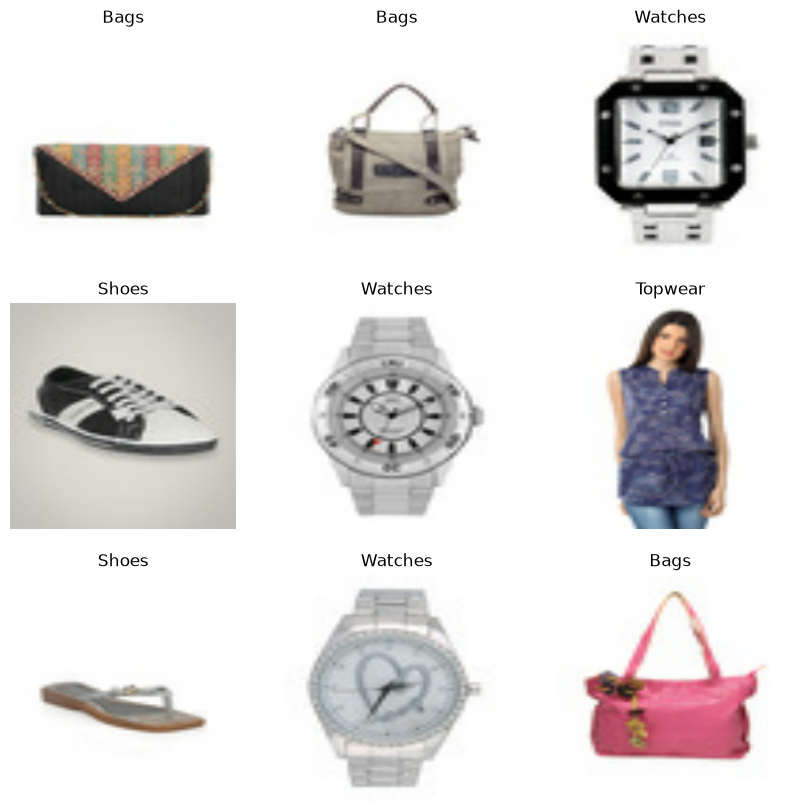

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

# In train_data there are images and 
# labels and there are 32 batches in that we selected batch 1 i.e take(1)
for images, labels in train_data.take(1):
    for i in range(9): # select 9 images
        ax = plt.subplot(3,3,i+1) # 3*3 box and i+1 position the image
        plt.imshow(images[i].numpy().astype("uint8")) # Converts pixel to img
        plt.title(train_data.class_names[labels[i]]) # TF uses internally numbers
        plt.axis("off") # removes x & y so image look closer
plt.show()

In [8]:
# Image Preprocessing: Normalizzation i.e 0 -> 255 to 0 -> 1
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(
    lambda images, labels: (normalization_layer(images), labels)
    
)

validation_data = validation_data.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_data = test_data.map(
    lambda images, labels: (normalization_layer(images),labels)
)

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [10]:
class_names = ['Bags', 'Shoes', 'Topwear', 'Watches']

In [11]:
for images, labels in train_data.take(1):
    print("Minimum pixel value:", images[0].numpy().min())
    print("Maximum pixel value:", images[0].numpy().max())

Minimum pixel value: 0.041053925
Maximum pixel value: 1.0


In [12]:
print(images[0].shape)

(224, 224, 3)


In [13]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 6400 files belonging to 4 classes.


In [14]:
validation_data = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 800 files belonging to 4 classes.


In [15]:
validation_data = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 800 files belonging to 4 classes.


In [16]:
for images, labels in train_data.take(1):
    print("Minimum:", images[0].numpy().min())
    print("Maximum:", images[0].numpy().max())

Minimum: 31.41943
Maximum: 255.0


In [17]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [18]:
train_data = train_data.map(
    lambda images, labels: (normalization_layer(images), labels)
)

validation_data = validation_data.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_data = test_data.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [19]:
for images, labels in train_data.take(1):
    print("Minimum:", images[0].numpy().min())
    print("Maximum:", images[0].numpy().max())

Minimum: 0.07758985
Maximum: 1.0


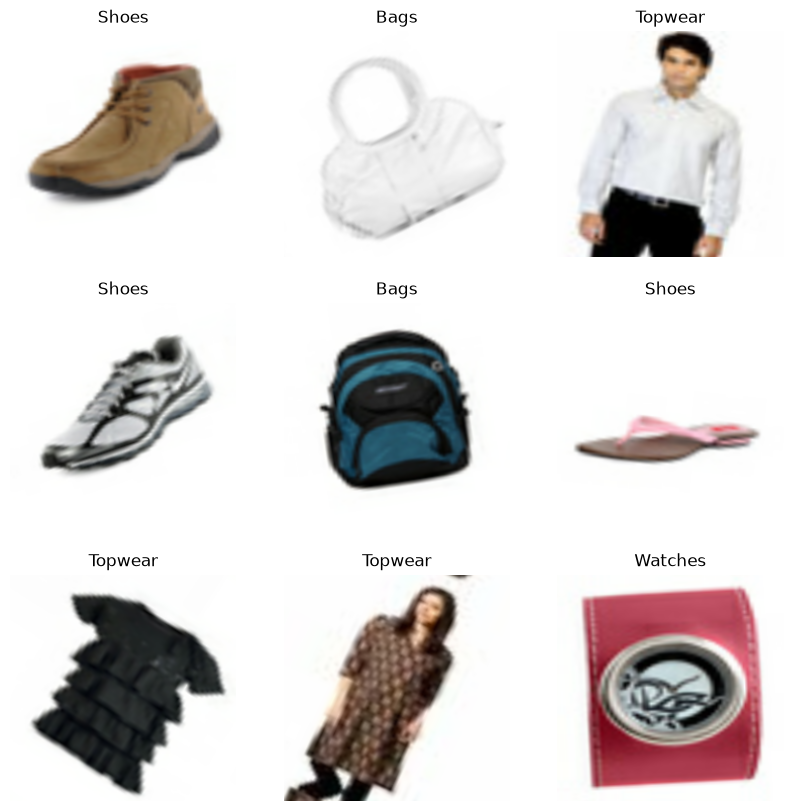

In [20]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):

    plt.figure(figsize=(10, 10))

    for i in range(9):
        augmented_image = data_augmentation(images[i])

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(augmented_image.numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.show()

In [22]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([
    
    Input(shape=(224, 224, 3)),
    
    data_augmentation,
    
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(128, activation="relu"),
    Dropout(0.5),
    
    Dense(4, activation="softmax")
])

In [27]:
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
history = cnn_model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10


d:\Projects\ML\.venv_ml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


200/200 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.8016 - loss: 0.6051 - val_accuracy: 0.9375 - val_loss: 0.1962
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9325 - loss: 0.2420 - val_accuracy: 0.9613 - val_loss: 0.1348
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9447 - loss: 0.1872 - val_accuracy: 0.9762 - val_loss: 0.1116
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.9575 - loss: 0.1445 - val_accuracy: 0.9787 - val_loss: 0.0796
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9630 - loss: 0.1321 - val_accuracy: 0.9737 - val_loss: 0.0753
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.9692 - loss: 0.1096 - val_accuracy: 0.9812 - val_loss: 0.0666
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.9711 - loss: 0.1086 - val_accuracy: 0.9850 - val_loss: 0.0689
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9742 - loss: 0.0965 - val_accuracy: 0.978

In [30]:
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,508,430 (127.82 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,954 (85.22 MB)

In [31]:
test_loss, test_accuracy = cnn_model.evaluate(test_data)

print("Test Loss", test_loss)
print("Test Accuracy:", test_accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 286ms/step - accuracy: 0.2500 - loss: 10.4124
Test Loss 10.412442207336426
Test Accuracy: 0.25


In [32]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    
    predictions = cnn_model.predict(images, verbose=0)
    
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [33]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        Bags       0.00      0.00      0.00       200
       Shoes       0.00      0.00      0.00       200
     Topwear       0.25      1.00      0.40       200
     Watches       0.00      0.00      0.00       200

    accuracy                           0.25       800
   macro avg       0.06      0.25      0.10       800
weighted avg       0.06      0.25      0.10       800



d:\Projects\ML\.venv_ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projects\ML\.venv_ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projects\ML\.venv_ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


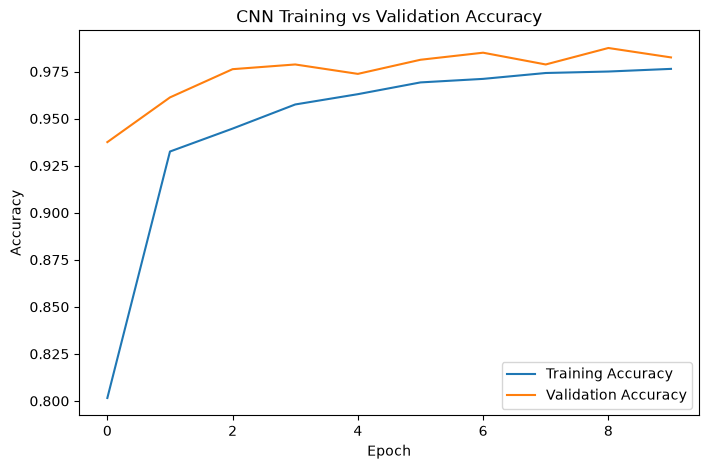

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

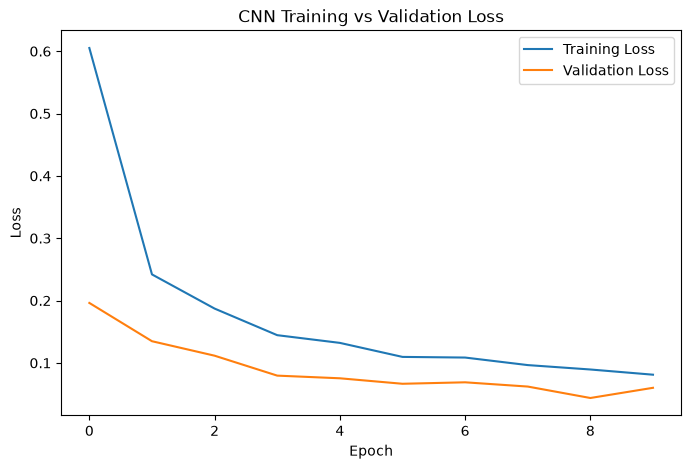

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.show()

In [37]:
for images, labels in train_data.take(1):
    print("Train:", tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())

for images, labels in validation_data.take(1):
    print("Validation:", tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())

for images, labels in test_data.take(1):
    print("Test:", tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())

Train: 0.0 1.0
Validation: 0.0 1.0
Test: 4.7076463e-07 0.003921569


In [38]:
prediction_counts = np.bincount(y_pred, minlength=4)

for i, count in enumerate(prediction_counts):
    print(class_names[i], ":", count)

Bags : 0
Shoes : 0
Topwear : 800
Watches : 0


In [40]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

test_data = test_data.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [41]:
for images, labels in test_data.take(1):
    print("Test:", tf.reduce_min(images).numpy(),
          tf.reduce_max(images).numpy())

Test: 0.00012004498 1.0


In [42]:
test_loss, test_accuracy = cnn_model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.9825 - loss: 0.0544
Test Loss: 0.054408665746450424
Test Accuracy: 0.9825000166893005


In [43]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = cnn_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

        Bags       0.98      0.97      0.98       200
       Shoes       0.99      0.99      0.99       200
     Topwear       0.99      0.97      0.98       200
     Watches       0.97      0.99      0.98       200

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



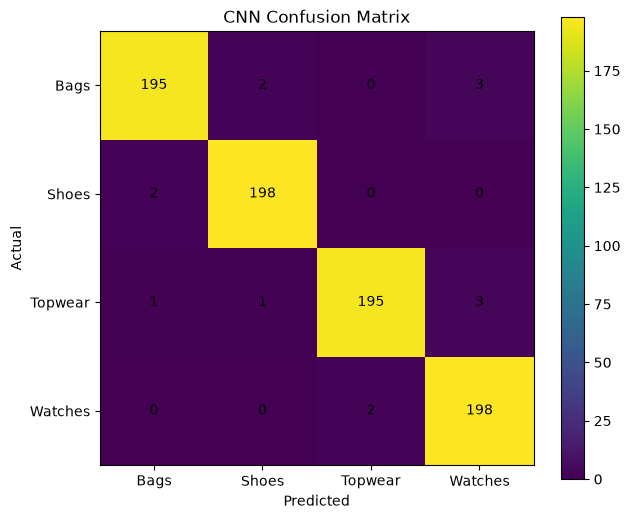

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.xticks(range(4), class_names)
plt.yticks(range(4), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [45]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential

In [46]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [47]:
vgg_base.trainable = False

In [48]:
vgg_model = Sequential([
    vgg_base,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(4, activation="softmax")
])

In [49]:
vgg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
vgg_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [51]:
vgg_history = vgg_model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

Epoch 1/5


d:\Projects\ML\.venv_ml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


200/200 ━━━━━━━━━━━━━━━━━━━━ 1470s 7s/step - accuracy: 0.8534 - loss: 0.5028 - val_accuracy: 0.9712 - val_loss: 0.1489
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 3761s 19s/step - accuracy: 0.9600 - loss: 0.1542 - val_accuracy: 0.9850 - val_loss: 0.0764
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1512s 8s/step - accuracy: 0.9733 - loss: 0.1050 - val_accuracy: 0.9862 - val_loss: 0.0547
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1620s 8s/step - accuracy: 0.9783 - loss: 0.0833 - val_accuracy: 0.9900 - val_loss: 0.0434
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1616s 8s/step - accuracy: 0.9817 - loss: 0.0716 - val_accuracy: 0.9900 - val_loss: 0.0410


In [52]:
vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(test_data)

print("VGG16 Test Loss:", vgg_test_loss)
print("VGG16 Test Accuracy:", vgg_test_accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 149s 6s/step - accuracy: 0.9962 - loss: 0.0258
VGG16 Test Loss: 0.025847317650914192
VGG16 Test Accuracy: 0.9962499737739563


In [53]:
y_true_vgg = []
y_pred_vgg = []

for images, labels in test_data:
    predictions = vgg_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true_vgg.extend(labels.numpy())
    y_pred_vgg.extend(predicted_classes)

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

print(classification_report(
    y_true_vgg,
    y_pred_vgg,
    target_names=class_names
))

              precision    recall  f1-score   support

        Bags       1.00      1.00      1.00       200
       Shoes       1.00      1.00      1.00       200
     Topwear       0.99      0.99      0.99       200
     Watches       1.00      0.99      0.99       200

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [56]:
cnn_accuracy = 0.9825
vgg_accuracy = vgg_test_accuracy

print("CNN Test Accuracy:", cnn_accuracy)
print("VGG16 Test Accuracy:", vgg_accuracy)

CNN Test Accuracy: 0.9825
VGG16 Test Accuracy: 0.9962499737739563


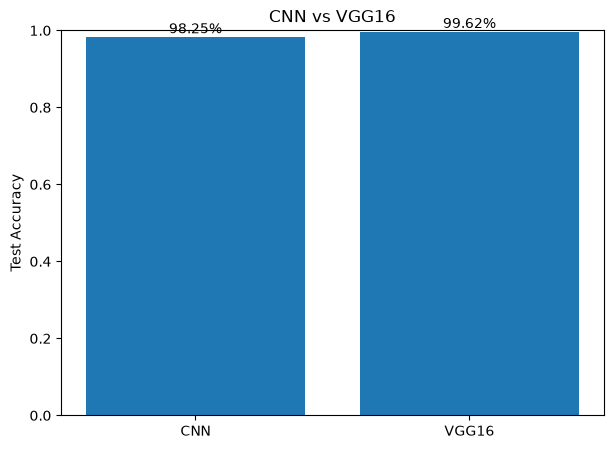

In [57]:
models = ["CNN", "VGG16"]
accuracies = [cnn_accuracy, vgg_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)

plt.ylabel("Test Accuracy")
plt.title("CNN vs VGG16")
plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.01, f"{value:.2%}", ha="center")

plt.show()

In [58]:
cnn_model.save("cnn_product_classifier.keras")
vgg_model.save("vgg16_product_classifier.keras")

In [59]:
print("===== MODEL COMPARISON =====")
print(f"CNN Test Accuracy   : {cnn_accuracy:.2%}")
print(f"VGG16 Test Accuracy : {vgg_test_accuracy:.2%}")

===== MODEL COMPARISON =====
CNN Test Accuracy   : 98.25%
VGG16 Test Accuracy : 99.62%


In [4]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
cnn_model = tf.keras.models.load_model(
    r"D:\Projects\ML\E-Commerce_Visual_product_classification\cnn_product_classifier.keras"
)

vgg_model = tf.keras.models.load_model(
    r"D:\Projects\ML\E-Commerce_Visual_product_classification\vgg16_product_classifier.keras"
)

In [6]:
test_path = r"D:\Projects\ML\E-Commerce_Visual_product_classification\product_dataset\test"

test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 800 files belonging to 4 classes.


In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

test_data = test_data.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [8]:
for images, labels in test_data.take(1):
    print(
        "Test range:",
        tf.reduce_min(images).numpy(),
        tf.reduce_max(images).numpy()
    )

Test range: 0.00012004498 1.0


In [9]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_data, verbose=1)

vgg_loss, vgg_accuracy = vgg_model.evaluate(test_data, verbose=1)

print("CNN Test Accuracy:", cnn_accuracy)
print("VGG16 Test Accuracy:", vgg_accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.9825 - loss: 0.0544
25/25 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.9962 - loss: 0.0258
CNN Test Accuracy: 0.9825000166893005
VGG16 Test Accuracy: 0.9962499737739563
